<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        DBSCAN: Agrupamiento Basado en Densidad y Ruido 🌌
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/04%20-%20Clustering%20No%20Supervisado/03_DBSCAN.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 2.4.3 (*DBSCAN*)** del Capítulo 2. *K-Means* y el jerárquico entienden un grupo como una región **compacta** alrededor de un centro. *DBSCAN* (*Density-Based Spatial Clustering of Applications with Noise*; Ester, Kriegel, Sander & Xu, 1996) propone otra idea: **un grupo es una región densa de puntos separada de otras por regiones ralas**. De ahí salen sus tres virtudes (formas arbitrarias, número de grupos automático y detección de ruido) y también sus limitaciones. Lo formulamos, **programamos desde cero** y **verificamos contra `sklearn.cluster.DBSCAN`**.

Al terminar podrás:

1. **Definir** con precisión $\varepsilon$-vecindad, punto **núcleo**, **borde** y **ruido**, **alcanzabilidad por densidad** y **conectividad por densidad**.
2. **Implementar** DBSCAN desde cero y **verificar** que produce la misma partición que `scikit-learn`, **documentando** el único caso ambiguo (puntos borde alcanzables desde dos grupos).
3. **Elegir $\varepsilon$** con el **gráfico de $k$-distancias** y justificar por qué un punto es núcleo si y solo si su $k$-distancia es $\le\varepsilon$.
4. **Medir la sensibilidad** a $\varepsilon$ y `min_samples`, y capturar **formas arbitrarias** (lunas, círculos) donde *K-Means* y los jerárquicos compactos fallan.
5. **Usar** el ruido (`-1`) como **detector de *outliers***.
6. **Reconocer las limitaciones**: **densidades variables** y **alta dimensión**, y conocer las extensiones **OPTICS** y **HDBSCAN**.

> 📍 **Dónde estamos:** Módulo 04, cuaderno 4 de 5. Venimos del [Clustering Jerárquico](02_Clustering_Jerarquico.ipynb) y de [K-Means](01_KMeans.ipynb). Sigue el [cuaderno de métricas](04_Metricas_de_Clustering.ipynb), donde veremos por qué silueta y Calinski–Harabasz **penalizan injustamente** a DBSCAN y qué métrica (DBCV) sí lo evalúa bien.

> 🔗 **Para no repetir:** el uso práctico de `DBSCAN` está en [Data Science Programming — Módulo 10 (cuaderno 04)](../../Data%20Science%20programming/10%20-%20Clustering/04_DBSCAN_Clustering.ipynb) y en [Data Mining — Módulo 03 (cuaderno 02)](../../Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/02_Clustering_Basado_en_Densidad_DBSCAN.ipynb). Aquí profundizamos en **definiciones formales, implementación propia, elección de parámetros y limitaciones**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 8 (*Unsupervised Learning Techniques*), sección *DBSCAN* (incluye el uso de `eps`, `min_samples`, puntos núcleo, anomalías y el clasificador *k*-NN para etiquetar nuevos puntos) y *Other Clustering Algorithms* (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt, 2015). Cap. 11 (*Working with Unlabeled Data – Clustering Analysis*): *Locating regions of high density via DBSCAN* (disponible en `Machine Learning/Libros/`).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Cap. 14 (*Unsupervised Learning*): el *clustering* basado en densidad se menciona solo de pasada. *(Capítulo citado de memoria: verifica en tu edición.)*
- Ester, M., Kriegel, H.-P., Sander, J. & Xu, X. (1996), *A density-based algorithm for discovering clusters in large spatial databases with noise*, **KDD-96**: 226–231 *(citado de memoria, verificar)*.
- Schubert, E., Sander, J., Ester, M., Kriegel, H.-P. & Xu, X. (2017), *DBSCAN revisited, revisited: why and how you should (still) use DBSCAN*, **ACM TODS** 42(3), art. 19 *(citado de memoria, verificar)*: reglas para elegir `min_samples` y $\varepsilon$ y aclaraciones sobre puntos borde.
- Ankerst, M., Breunig, M. M., Kriegel, H.-P. & Sander, J. (1999), *OPTICS: ordering points to identify the clustering structure*, **SIGMOD 1999** *(citado de memoria, verificar)*.
- Campello, R. J. G. B., Moulavi, D. & Sander, J. (2013), *Density-based clustering based on hierarchical density estimates*, **PAKDD 2013** *(citado de memoria, verificar)*: HDBSCAN.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Clustering — DBSCAN](https://scikit-learn.org/stable/modules/clustering.html#dbscan) · [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) · [`OPTICS`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html) · [`HDBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html)
- [scikit-learn: Demo of DBSCAN clustering algorithm](https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html)

---
## 1. Conceptos: Núcleo, Borde y Ruido 🧱

### 1.1 Definiciones (Ester et al., 1996)

Dados un radio $\varepsilon>0$ y un entero `min_samples` $=m$:

- **$\varepsilon$-vecindad** de $p$: $\;N_\varepsilon(p)=\{q\in X: d(p,q)\le\varepsilon\}$. **Incluye a $p$ mismo** (convención de `scikit-learn`).
- **Punto núcleo** (*core*): $|N_\varepsilon(p)|\ge m$. Está en una zona densa.
- **Directamente alcanzable por densidad**: $q$ lo es desde $p$ si $q\in N_\varepsilon(p)$ **y $p$ es núcleo**. (La relación **no es simétrica**: un borde es alcanzable desde un núcleo, pero no al revés.)
- **Alcanzable por densidad**: existe una cadena $p=p_1,\dots,p_k=q$ donde cada $p_{i+1}$ es directamente alcanzable desde $p_i$.
- **Conectados por densidad**: $p$ y $q$ lo están si existe un punto $o$ desde el cual **ambos** son alcanzables (esta relación **sí** es simétrica).
- **Grupo (*cluster*)**: conjunto **no vacío, maximal y conectado por densidad**: todo punto alcanzable desde un miembro del grupo pertenece al grupo.
- **Punto borde** (*border*): no es núcleo pero está en la vecindad de algún núcleo (pertenece a un grupo, en su orilla).
- **Ruido** (*noise*): no pertenece a ningún grupo (etiqueta `-1` en `scikit-learn`).

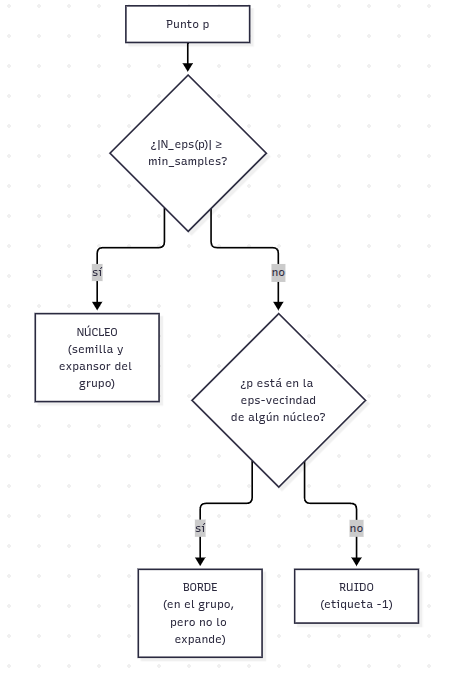

### 1.2 Algoritmo

> **Para** cada punto $p$, en orden de índice, **no visitado y núcleo**: crear un grupo nuevo y **expandirlo**: añadir todos los puntos de $N_\varepsilon(p)$; por cada **núcleo** añadido, añadir también su vecindad (los bordes se etiquetan pero **no** se expanden). Los puntos que nadie alcanza quedan como ruido.

Cada punto se «consulta» una vez, así que el costo es el de las consultas de vecindad: $O(n^2)$ con la matriz completa (nuestra implementación), $O(n\log n)$ con un índice espacial (árbol $k$-d o *ball tree*) en baja dimensión y **$O(n^2)$ en el peor caso**.

### 1.3 Determinismo y el caso ambiguo

Los **núcleos** y el **ruido** están **determinados** por los datos y los parámetros: no dependen del orden. Los grupos formados por núcleos también (son las componentes conexas del grafo de núcleos a distancia $\le\varepsilon$). **Lo único ambiguo** son los **puntos borde alcanzables desde núcleos de dos grupos distintos**: se asignan **al primer grupo que los alcanza**, que depende del **orden de los datos**. `scikit-learn` procesa en orden de índice y numera los grupos por el índice de su primer núcleo; si nuestra implementación sigue esa misma convención, la partición coincide **exactamente**. Lo verificamos, y mostramos el caso ambiguo con un ejemplo unidimensional.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN, KMeans, OPTICS
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d"]
print("Entorno listo.")

In [ ]:
# ============================================================
# 1. DBSCAN DESDE CERO, verificado contra sklearn.cluster.DBSCAN
# ============================================================
def dbscan_desde_cero(X, eps, min_samples):
    """DBSCAN con la misma convencion que sklearn:
    - la eps-vecindad INCLUYE al propio punto y usa 'distancia <= eps';
    - se recorre en orden de indice; los grupos se numeran por el indice de su primer nucleo;
    - un punto borde queda con el PRIMER grupo que lo alcanza.
    Devuelve (etiquetas con -1 = ruido, mascara de nucleos). Costo O(n^2) por la matriz de distancias."""
    n = len(X)
    D = cdist(X, X)
    vecinos = [np.flatnonzero(D[i] <= eps) for i in range(n)]           # eps-vecindades (incluyen a i)
    nucleo = np.array([len(v) >= min_samples for v in vecinos])
    etiquetas = np.full(n, -1)
    c = 0
    for i in range(n):
        if etiquetas[i] != -1 or not nucleo[i]:
            continue                                                    # ya asignado, o no es semilla valida
        etiquetas[i] = c
        pila = [i]
        while pila:                                                     # expansion del grupo c
            p = pila.pop()
            if not nucleo[p]:
                continue                                                # un borde se etiqueta pero NO expande
            for q in vecinos[p]:
                if etiquetas[q] == -1:
                    etiquetas[q] = c
                    pila.append(q)
        c += 1
    return etiquetas, nucleo

# --- Verificacion en cuatro conjuntos con distintos (eps, min_samples) ---
rng = np.random.RandomState(SEED)
Xm = np.vstack([make_moons(500, noise=0.08, random_state=SEED)[0], rng.uniform([-1.5, -1], [2.5, 1.5], size=(30, 2))])
bancos = {"lunas + ruido": (Xm, 0.2, 5),
          "círculos": (make_circles(400, factor=0.4, noise=0.05, random_state=SEED)[0], 0.15, 5),
          "blobs": (make_blobs(500, centers=4, cluster_std=0.9, random_state=SEED)[0], 0.7, 8),
          "uniforme 3D": (rng.uniform(size=(500, 3)), 0.12, 6)}
filas = []
for nombre, (X, eps, m) in bancos.items():
    mi_lab, mi_nuc = dbscan_desde_cero(X, eps, m)
    sk = DBSCAN(eps=eps, min_samples=m, algorithm="kd_tree").fit(X)
    sk_nuc = np.zeros(len(X), dtype=bool); sk_nuc[sk.core_sample_indices_] = True
    assert np.array_equal(mi_nuc, sk_nuc), nombre                        # mismos puntos nucleo
    assert np.array_equal(mi_lab == -1, sk.labels_ == -1), nombre        # mismo ruido
    assert np.array_equal(mi_lab, sk.labels_), nombre                    # misma particion y misma numeracion
    filas.append({"conjunto": nombre, "eps": eps, "min_samples": m, "grupos": mi_lab.max() + 1, "núcleos": int(mi_nuc.sum()),
                  "bordes": int(((mi_lab != -1) & ~mi_nuc).sum()), "ruido": int((mi_lab == -1).sum())})
print("DBSCAN propio == sklearn.cluster.DBSCAN (núcleos, ruido y etiquetas idénticos) en los 4 conjuntos.")
display(pd.DataFrame(filas))

# --- El caso ambiguo: un punto borde alcanzable desde dos grupos ---
P = np.array([0, 0.5, 1.0, 1.5, 2.5, 3.5, 4.0, 4.5, 5.0])[:, None] * np.array([[1.0, 0.0]])   # el punto 2.5 es borde de ambos lados
for nombre, perm in [("orden original", np.arange(9)), ("orden invertido", np.arange(9)[::-1])]:
    Q = P[perm]
    lab, nuc = dbscan_desde_cero(Q, eps=1.0, min_samples=4)
    sk = DBSCAN(eps=1.0, min_samples=4, algorithm="kd_tree").fit(Q)
    assert np.array_equal(lab, sk.labels_)                               # coincide con sklearn en ambos ordenes
    i25 = int(np.flatnonzero(Q[:, 0] == 2.5)[0])
    izq = np.flatnonzero(Q[:, 0] < 2.5)
    pertenece = "grupo IZQUIERDO (puntos 0 a 1.5)" if lab[i25] == lab[izq[0]] else "grupo DERECHO (puntos 3.5 a 5)"
    print(f"{nombre:16s}: x = 2.5 es borde (núcleo: {bool(nuc[i25])}) y queda en el {pertenece}")
print("\nLos núcleos, el ruido y los dos grupos 'de núcleos' son idénticos en ambos órdenes; solo cambia a qué grupo se adjunta el punto borde ambiguo.")

In [ ]:
# ============================================================
# 1b. Visualizacion de los tipos de punto y de la eps-vecindad
# ============================================================
rng = np.random.RandomState(1)
Xv = np.vstack([make_moons(260, noise=0.07, random_state=1)[0], rng.uniform([-1.3, -0.8], [2.3, 1.3], size=(12, 2))])
eps_v, m_v = 0.17, 5
lab, nuc = dbscan_desde_cero(Xv, eps_v, m_v)
borde = (lab != -1) & ~nuc
ruido = lab == -1

fig, ax = plt.subplots(figsize=(10.5, 5.6))
for g in range(lab.max() + 1):
    ax.scatter(*Xv[(lab == g) & nuc].T, s=46, color=PALETA[g], edgecolor="black", lw=0.5, label=f"núcleo (grupo {g})")
    ax.scatter(*Xv[(lab == g) & borde].T, s=40, color=PALETA[g], marker="s", edgecolor="black", lw=0.5, label=f"borde (grupo {g})")
ax.scatter(*Xv[ruido].T, s=60, color="gray", marker="x", lw=2, label="ruido")
# eps-vecindades de tres puntos representativos: un nucleo, un borde y uno de ruido
for etiqueta, idx in [("núcleo", np.flatnonzero(nuc)[10]), ("borde", np.flatnonzero(borde)[0]), ("ruido", np.flatnonzero(ruido)[0])]:
    ax.add_patch(Circle(Xv[idx], eps_v, fill=False, ls="--", color="black", lw=1.2))
    ax.annotate(etiqueta, Xv[idx] + [0.05, eps_v + 0.05], fontsize=9, fontweight="bold")
ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title(f"DBSCAN (ε = {eps_v}, min_samples = {m_v}): núcleos, bordes y ruido; círculos = ε-vecindad", fontweight="bold")
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()
print(f"Núcleos: {nuc.sum()} | bordes: {borde.sum()} | ruido: {ruido.sum()}")

---
##### 🛠️ Práctica 1: Núcleo, borde y ruido en un conjunto de seis puntos

Clasifica a mano (y luego con código) los puntos de una recta usando `dbscan_desde_cero` de la Sección 1. Los puntos son $x=0,\,0.5,\,1,\,1.5,\,2$ y $x=5$ (todos con $y=0$):

1. Define `P = np.array([[0, 0], [0.5, 0], [1, 0], [1.5, 0], [2, 0], [5, 0]], dtype=float)`.
2. Con `eps=0.6` y `min_samples=3` obtén `lab, nuc = dbscan_desde_cero(P, 0.6, 3)`; cuenta `n_nucleo`, `n_borde` y `n_ruido` (borde = asignado a un grupo pero no núcleo).
3. Verifica con `assert` que hay 3 núcleos, 2 bordes y 1 punto de ruido, y que el punto $x=5$ es el ruido.
4. Repite con `eps=0.4` (todos quedan como ruido: nadie tiene vecinos) y con `min_samples=2` (con `eps=0.6`: 5 núcleos, 0 bordes). Verifica ambos casos con `assert`.

In [ ]:
# Escribe tu código aquí

# P = np.array([[0, 0], [0.5, 0], [1, 0], [1.5, 0], [2, 0], [5, 0]], dtype=float)
# lab, nuc = dbscan_desde_cero(P, 0.6, 3)
# n_nucleo = int(nuc.sum())
# n_borde = int(((lab != -1) & ~nuc).sum())
# n_ruido = int((lab == -1).sum())
# assert ...
# lab2, nuc2 = dbscan_desde_cero(P, 0.4, 3)      # eps muy chico
# lab3, nuc3 = dbscan_desde_cero(P, 0.6, 2)      # min_samples bajo


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
P = np.array([[0, 0], [0.5, 0], [1, 0], [1.5, 0], [2, 0], [5, 0]], dtype=float)

def conteo(lab, nuc):
    return int(nuc.sum()), int(((lab != -1) & ~nuc).sum()), int((lab == -1).sum())   # (nucleos, bordes, ruido)

# eps = 0.6 y min_samples = 3: los puntos 0.5, 1 y 1.5 tienen 3 vecinos (incluido el propio); 0 y 2 solo 2
lab, nuc = dbscan_desde_cero(P, 0.6, 3)
n_nucleo, n_borde, n_ruido = conteo(lab, nuc)
print(f"eps=0.6, m=3 -> nucleos {n_nucleo}, bordes {n_borde}, ruido {n_ruido} | etiquetas {lab.tolist()}")
assert (n_nucleo, n_borde, n_ruido) == (3, 2, 1) and lab[5] == -1 and not nuc[5]

# eps muy chico: ningun punto alcanza 3 vecinos (la separacion minima es 0.5 > 0.4)
lab2, nuc2 = dbscan_desde_cero(P, 0.4, 3)
print(f"eps=0.4, m=3 -> {conteo(lab2, nuc2)}")
assert (lab2 == -1).all()

# min_samples bajo: casi todos pasan a ser nucleo (0 y 2 tienen 2 vecinos contandose a si mismos)
lab3, nuc3 = dbscan_desde_cero(P, 0.6, 2)
print(f"eps=0.6, m=2 -> {conteo(lab3, nuc3)}")
assert conteo(lab3, nuc3) == (5, 0, 1)
print("Los tres tipos de punto dependen de (eps, min_samples): el aislado siempre es ruido, los extremos del grupo son bordes o nucleos segun m.")
```
</details>

---


---
## 2. Elegir $\varepsilon$: el Gráfico de $k$-Distancias 📈

### 2.1 Una equivalencia útil

Sea $k=$ `min_samples` y $d_k(p)$ la **$k$-distancia** de $p$: la distancia a su **$k$-ésimo vecino más cercano contando al propio punto** (el primer «vecino» es $p$ a distancia 0). Entonces

$$|N_\varepsilon(p)|\ge k\iff d_k(p)\le\varepsilon,$$

es decir, **$p$ es núcleo si y solo si su $k$-distancia es $\le\varepsilon$**. Esto convierte la elección de $\varepsilon$ en una pregunta sobre la **distribución de las $k$-distancias**: los puntos en zonas densas tienen $k$-distancia **pequeña**; el ruido, **grande**.

### 2.2 El gráfico

Se ordenan las $k$-distancias de **menor a mayor** (o de mayor a menor, como en el artículo original). La curva tiene un tramo **plano** (puntos de grupos) y, al final, un **ascenso brusco** (ruido). El **codo** de esa curva es un buen candidato a $\varepsilon$: por debajo de él, los puntos de los grupos son núcleos; por encima, el ruido no se funde con los grupos. Para automatizar la lectura usamos la misma heurística de la cuerda del cuaderno de *K-Means* (el punto más alejado de la recta que une los extremos), con la salvedad habitual: **es una ayuda, no un oráculo**.

### 2.3 Elegir `min_samples`

Regla práctica (Schubert et al., 2017; *citado de memoria, verificar*): **`min_samples` $\ge d+1$**, y **$\approx 2d$** si hay mucho ruido o conjuntos grandes; en 2D, valores de 4 a 10. Un `min_samples` **mayor** exige más densidad: más puntos se declaran ruido y los grupos pequeños desaparecen.

In [ ]:
# ============================================================
# 2. Grafico de k-distancias, equivalencia nucleo <=> k-distancia <= eps y eleccion de eps
# ============================================================
def k_distancias(X, k):
    """k-distancia de cada punto: distancia al k-esimo vecino contando al propio punto (columna k-1 de las distancias ordenadas)."""
    return np.sort(cdist(X, X), axis=1)[:, k - 1]

m = 5
kd = k_distancias(Xm, m)
kd_ord = np.sort(kd)                                                    # ascendente
x = np.arange(len(kd_ord)) / (len(kd_ord) - 1); y = (kd_ord - kd_ord[0]) / (kd_ord[-1] - kd_ord[0])
i_codo = int(np.argmax((x - y) / np.sqrt(2)))                           # punto mas alejado de la cuerda
eps_codo = float(kd_ord[i_codo])

# Equivalencia: nucleo <=> k-distancia <= eps  (se verifica para varios eps)
for eps_t in [0.1, eps_codo, 0.2, 0.3]:
    _, nuc_t = dbscan_desde_cero(Xm, eps_t, m)
    assert np.array_equal(nuc_t, kd <= eps_t)
print(f"Equivalencia núcleo <=> {m}-distancia <= eps verificada. Codo de la curva: eps ≈ {eps_codo:.3f}")

lab_c, _ = dbscan_desde_cero(Xm, eps_codo, m)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(np.arange(len(kd_ord)), kd_ord, color=PALETA[0], lw=2)
axes[0].axhline(eps_codo, color=PALETA[1], ls="--", label=f"codo: eps ≈ {eps_codo:.3f}")
axes[0].axvline(i_codo, color="gray", ls=":")
axes[0].set_xlabel("Puntos ordenados por su k-distancia (menor a mayor)"); axes[0].set_ylabel(f"{m}-distancia")
axes[0].set_title(f"Gráfico de k-distancias (k = min_samples = {m})", fontweight="bold"); axes[0].legend()
for g in np.unique(lab_c):
    sel = lab_c == g
    axes[1].scatter(*Xm[sel].T, s=12 if g >= 0 else 40, color="gray" if g < 0 else PALETA[g], marker="x" if g < 0 else "o", alpha=0.8,
                    label="ruido" if g < 0 else f"grupo {g}")
axes[1].set_title(f"DBSCAN con eps = {eps_codo:.3f}: {lab_c.max() + 1} grupos, {int((lab_c == -1).sum())} ruido", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

---
##### 🛠️ Práctica 2: Elegir ε con el percentil 95 de las $k$-distancias

El codo del gráfico de $k$-distancias es una guía, pero hay otra lectura directa de la equivalencia «núcleo $\iff$ $k$-distancia $\le\varepsilon$»: si eliges `eps` como el **percentil 95** de las $k$-distancias, el 95 % de los puntos serán núcleos. Compruébalo con `k_distancias` y `dbscan_desde_cero` de la Sección 2, sobre datos nuevos:

1. Genera `Xb = make_blobs(300, centers=3, cluster_std=0.6, random_state=SEED)[0]` y calcula `kd = k_distancias(Xb, 5)`.
2. Define `eps_p95 = np.percentile(kd, 95)` y ejecuta `lab, nuc = dbscan_desde_cero(Xb, eps_p95, 5)`.
3. Verifica con `assert` que `nuc` coincide exactamente con `kd <= eps_p95` y que la fracción de núcleos es al menos $0.95$.
4. Cuenta los grupos y el ruido, y comprueba con `assert` que hay 3 grupos y a lo sumo 10 puntos de ruido.

In [ ]:
# Escribe tu código aquí

# Xb = make_blobs(300, centers=3, cluster_std=0.6, random_state=SEED)[0]
# kd = k_distancias(Xb, 5)
# eps_p95 = np.percentile(kd, 95)
# lab, nuc = dbscan_desde_cero(Xb, eps_p95, 5)
# assert np.array_equal(nuc, kd <= eps_p95)
# n_grupos = ...
# n_ruido = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Tres grupos compactos y sus 5-distancias
Xb = make_blobs(300, centers=3, cluster_std=0.6, random_state=SEED)[0]
kd = k_distancias(Xb, 5)

# 2) eps = percentil 95: el 95 % de los puntos tiene 5-distancia <= eps
eps_p95 = np.percentile(kd, 95)
lab, nuc = dbscan_desde_cero(Xb, eps_p95, 5)

# 3) Equivalencia: nucleo <=> k-distancia <= eps
assert np.array_equal(nuc, kd <= eps_p95)
assert nuc.mean() >= 0.95

# 4) Resultado del agrupamiento
n_grupos = int(lab.max() + 1)
n_ruido = int((lab == -1).sum())
print(f"eps = {eps_p95:.3f} | nucleos: {nuc.mean():.1%} | grupos: {n_grupos} | ruido: {n_ruido}")
assert n_grupos == 3 and n_ruido <= 10
print("Con grupos compactos y poco ruido, el percentil 95 da un eps que recupera los 3 grupos.")
```
</details>

---


---
### 2.4 Sensibilidad a $\varepsilon$ y `min_samples`

El gráfico de $k$-distancias da un valor de partida, pero conviene **ver el paisaje completo**. Variamos $\varepsilon$ y `min_samples` y medimos el ARI contra la verdad. Una precaución: DBSCAN puede dejar puntos **sin asignar**. Si tratáramos `-1` como «un grupo más», un algoritmo que declara *todo* ruido recibiría una nota ridículamente buena en algunos casos. Para evitarlo, **cada punto de ruido cuenta como un grupo de un solo elemento** antes de calcular el ARI: dejar puntos sin asignar **penaliza**. (Los puntos de ruido uniforme que añadimos a las lunas se tratan igual: no pertenecen a ningún grupo real, así que también cuentan como singletons en la verdad.)

In [ ]:
# ============================================================
# 2b. Paisaje de sensibilidad: ARI en funcion de (eps, min_samples)
# ============================================================
def ari_ruido_singleton(y_verdad, etiquetas):
    """ARI donde cada punto de ruido (-1) cuenta como su propio grupo de un solo elemento, en la verdad y en la prediccion."""
    def singletons(v):
        v = np.asarray(v).copy(); m = v == -1
        v[m] = v.max() + 1 + np.arange(m.sum()); return v
    return adjusted_rand_score(singletons(y_verdad), singletons(etiquetas))

Xl, yl = make_moons(500, noise=0.08, random_state=SEED)
Xm_r = np.vstack([Xl, np.random.RandomState(SEED).uniform([-1.5, -1], [2.5, 1.5], size=(30, 2))])
y_r = np.r_[yl, np.full(30, -1)]                                       # los 30 puntos uniformes son ruido real

epss = np.round(np.linspace(0.05, 0.5, 10), 2); mss = [3, 5, 8, 12, 20, 30]
M = np.array([[ari_ruido_singleton(y_r, DBSCAN(eps=e, min_samples=s).fit_predict(Xm_r)) for e in epss] for s in mss])
fig, ax = plt.subplots(figsize=(10.5, 4.6))
sns.heatmap(M, annot=True, fmt=".2f", cmap="viridis", xticklabels=epss, yticklabels=mss, cbar_kws={"label": "ARI (ruido = singletons)"}, ax=ax)
ax.set_xlabel("eps"); ax.set_ylabel("min_samples"); ax.set_title("Lunas + ruido: DBSCAN funciona en una franja (eps, min_samples)", fontweight="bold")
plt.tight_layout(); plt.show()
mejor = np.unravel_index(np.argmax(M), M.shape)
print(f"Mejor combinación: eps = {epss[mejor[1]]}, min_samples = {mss[mejor[0]]} (ARI = {M.max():.2f}). "
      "Con eps muy pequeño todo es ruido; con eps muy grande los dos grupos se funden; min_samples alto exige demasiada densidad.")
assert M.max() > 0.85 and M.min() < 0.3

---
## 3. Formas Arbitrarias: Donde *K-Means* y los Enlaces Compactos Fallan 🌀

Como DBSCAN define el grupo por **conectividad de densidad** y no por cercanía a un centro, puede seguir **cualquier forma** (lunas, anillos, espirales), siempre que el grupo sea una región densa conexa y esté **separado** de los demás por una zona rala. Lo comparamos con *K-Means* y con el aglomerativo *Ward*, fijando para todos el número de grupos verdadero (ventaja que DBSCAN **no** necesita).

In [ ]:
# ============================================================
# 3. Lunas y circulos: DBSCAN vs. K-Means vs. Ward
# ============================================================
from scipy.cluster.hierarchy import linkage, fcluster
datos = {"Lunas": (make_moons(400, noise=0.06, random_state=SEED), 0.18, 5),
         "Círculos": (make_circles(400, factor=0.4, noise=0.05, random_state=SEED), 0.15, 5)}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
filas = []
for r, (nombre, ((X, y), eps, m)) in enumerate(datos.items()):
    lab_db = DBSCAN(eps=eps, min_samples=m).fit_predict(X)
    lab_km = KMeans(2, n_init=10, random_state=SEED).fit_predict(X)
    lab_wd = fcluster(linkage(X, method="ward"), 2, criterion="maxclust") - 1
    for c, (titulo, lab) in enumerate([(f"DBSCAN (eps={eps}, m={m})", lab_db), ("K-Means (K=2)", lab_km), ("Ward (K=2)", lab_wd)]):
        for g in np.unique(lab):
            axes[r, c].scatter(*X[lab == g].T, s=10, color="gray" if g < 0 else PALETA[g], marker="x" if g < 0 else "o", alpha=0.8)
        a = adjusted_rand_score(y, lab)
        axes[r, c].set_title(f"{nombre} — {titulo}\nARI = {a:.2f}", fontweight="bold", fontsize=10)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        filas.append({"conjunto": nombre, "algoritmo": titulo.split(" (")[0], "ARI": a})
plt.tight_layout(); plt.show()
display(pd.DataFrame(filas).pivot(index="conjunto", columns="algoritmo", values="ARI").round(3))
res = pd.DataFrame(filas).set_index(["conjunto", "algoritmo"])["ARI"]
assert res[("Lunas", "DBSCAN")] > 0.95 and res[("Círculos", "DBSCAN")] > 0.95
assert res[("Lunas", "K-Means")] < 0.5 and res[("Círculos", "K-Means")] < 0.1

---
## 4. El Ruido como Detector de *Outliers* 🚨

Una consecuencia directa de la definición: los puntos que **no** son alcanzables desde ningún núcleo quedan con etiqueta `-1`. Eso convierte a DBSCAN en un **detector de anomalías basado en densidad**. Es un uso razonable cuando los *outliers* son puntos **aislados** en zonas poco pobladas; es débil frente a **grupos pequeños y densos de anomalías** (que DBSCAN trataría como un grupo más) y exige que los grupos normales sean más densos que `min_samples` pueda detectar.

Medimos **precisión** (de lo que marca como ruido, ¿qué fracción son *outliers* reales?) y **recall** (de los *outliers* reales, ¿cuántos marca?), conceptos del [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb), sobre tres grupos gaussianos más 25 puntos dispersos uniformemente.

In [ ]:
# ============================================================
# 4. Deteccion de outliers con el ruido de DBSCAN
# ============================================================
rng = np.random.RandomState(SEED)
Xg, yg = make_blobs(n_samples=600, centers=[[-4, -3], [4, -3], [0, 4]], cluster_std=0.9, random_state=SEED)
Xo = rng.uniform(-9, 9, size=(25, 2))
Xa = np.vstack([Xg, Xo]); es_out = np.r_[np.zeros(len(Xg), bool), np.ones(len(Xo), bool)]    # verdad: los 25 uniformes son outliers

filas = []
for eps in [0.4, 0.6, 0.8, 1.0]:
    lab = DBSCAN(eps=eps, min_samples=8).fit_predict(Xa)
    marcado = lab == -1
    vp = int((marcado & es_out).sum())
    filas.append({"eps": eps, "marcados como ruido": int(marcado.sum()), "outliers detectados": vp,
                  "precisión": vp / max(marcado.sum(), 1), "recall": vp / es_out.sum()})
tabla = pd.DataFrame(filas).set_index("eps"); display(tabla.round(3))

eps_sel = 0.8
lab = DBSCAN(eps=eps_sel, min_samples=8).fit_predict(Xa)
fig, ax = plt.subplots(figsize=(8.5, 5.4))
for g in range(lab.max() + 1):
    ax.scatter(*Xa[lab == g].T, s=12, color=PALETA[g], alpha=0.7, label=f"grupo {g}")
ax.scatter(*Xa[lab == -1].T, s=70, marker="x", color="black", lw=1.8, label="ruido de DBSCAN")
ax.set_title(f"Outliers como ruido de DBSCAN (eps = {eps_sel}, min_samples = 8)", fontweight="bold")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
assert tabla.loc[0.8, "recall"] > 0.7 and tabla.loc[0.8, "precisión"] > 0.7
print("Con eps pequeño marca como ruido también puntos legítimos de los grupos (baja precisión); con eps grande se le escapan outliers (baja recall).")

---
## 5. Limitaciones: Densidades Variables y Alta Dimensión ⚠️

### 5.1 Un solo $\varepsilon$ para toda la data

DBSCAN usa **un único umbral de densidad global** $(\varepsilon, m)$. Si los grupos tienen **densidades muy distintas**:

- con $\varepsilon$ **pequeño**, el grupo **disperso** se desmorona en ruido;
- con $\varepsilon$ **grande**, los grupos **densos que están cerca** entre sí se **funden** en uno.

**No existe** un $\varepsilon$ que sirva para todos. Las extensiones resuelven esto:

| Extensión | Idea |
|---|---|
| **OPTICS** (Ankerst et al., 1999) | No fija $\varepsilon$: produce un **orden** de los puntos y su **distancia de alcanzabilidad**; los **valles** del gráfico de alcanzabilidad son grupos de distinta densidad. Extrae grupos con un umbral (`xi`). |
| **HDBSCAN** (Campello et al., 2013) | Combina DBSCAN con un **jerárquico** (*single linkage* sobre la **distancia de alcanzabilidad mutua**) y selecciona los grupos **más estables** del árbol: maneja densidades variables y solo requiere `min_cluster_size`. Comparte su maquinaria (alcanzabilidad mutua) con **DBCV** (cuaderno 04). |

Los comprobamos con dos grupos densos **cercanos** (separados por 0.9) y un grupo disperso: la **evaluación** usa el ARI con el ruido como singletons.

In [ ]:
# ============================================================
# 5a. Densidades variables: DBSCAN con varios eps vs. OPTICS vs. HDBSCAN
# ============================================================
try:
    from sklearn.cluster import HDBSCAN                                  # disponible desde scikit-learn 1.3
except ImportError:
    HDBSCAN = None

Xv, yv = make_blobs(n_samples=[150, 150, 300], centers=[[0, 0], [0.9, 0], [5, 3]], cluster_std=[0.12, 0.12, 0.9], random_state=SEED)

def n_grupos(lab):
    return len(set(lab)) - (1 if -1 in lab else 0)

paneles = []
for eps in [0.1, 0.3, 1.0]:
    paneles.append((f"DBSCAN eps = {eps}", DBSCAN(eps=eps, min_samples=10).fit_predict(Xv)))
opt = OPTICS(min_samples=10, xi=0.1, min_cluster_size=30).fit(Xv)
paneles.append(("OPTICS (xi = 0.1)", opt.labels_))
if HDBSCAN is not None:
    paneles.append(("HDBSCAN (min_cluster_size = 30)", HDBSCAN(min_cluster_size=30).fit_predict(Xv)))

fig, axes = plt.subplots(1, len(paneles), figsize=(4.2 * len(paneles), 4.4))
rows = []
for ax, (titulo, lab) in zip(axes, paneles):
    for g in np.unique(lab):
        ax.scatter(*Xv[lab == g].T, s=8, color="gray" if g < 0 else PALETA[g % len(PALETA)], marker="x" if g < 0 else "o", alpha=0.7)
    a = ari_ruido_singleton(yv, lab)
    ax.set_title(f"{titulo}\n{n_grupos(lab)} grupos, {int((lab == -1).sum())} ruido, ARI = {a:.2f}", fontsize=9, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([]); rows.append((titulo, a))
plt.tight_layout(); plt.show()

# Mejor DBSCAN posible sobre una rejilla fina de eps (con min_samples = 10)
mejor_db = max(ari_ruido_singleton(yv, DBSCAN(eps=e, min_samples=10).fit_predict(Xv)) for e in np.linspace(0.05, 1.5, 60))
print(f"Mejor ARI de DBSCAN sobre una rejilla de 60 valores de eps: {mejor_db:.2f}")
print("Ningún eps único sirve: los dos grupos densos solo se separan con eps pequeño, y entonces el grupo disperso se vuelve ruido.")
print("OPTICS y HDBSCAN, que trabajan con la jerarquía de densidades, recuperan los tres grupos.")
assert mejor_db < 0.85 and rows[3][1] > 0.9

In [ ]:
# ============================================================
# 5b. Reachability plot de OPTICS y 5c. Alta dimension: la mejor version de DBSCAN tambien se degrada
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
orden = opt.ordering_
reach = opt.reachability_[orden]; lab_o = opt.labels_[orden]
colores = ["lightgray" if g < 0 else PALETA[g % len(PALETA)] for g in lab_o]
axes[0].bar(np.arange(len(reach)), np.where(np.isinf(reach), np.nanmax(reach[np.isfinite(reach)]), reach), width=1.0, color=colores)
axes[0].set_xlabel("Puntos en el orden de OPTICS"); axes[0].set_ylabel("Distancia de alcanzabilidad")
axes[0].set_title("Gráfico de alcanzabilidad: cada valle es un grupo (distintas densidades)", fontweight="bold", fontsize=10)

# Alta dimension: 2 grupos separados en 2 variables + (d - 2) variables de ruido; se toma el MEJOR eps de una rejilla
dims = [2, 5, 10, 20, 50, 100]
curva = []
for d in dims:
    vals = []
    for s in range(3):
        Xs, ys = make_blobs(n_samples=300, centers=[[0, 0], [6, 0]], cluster_std=0.9, random_state=s)
        Xs = StandardScaler().fit_transform(np.hstack([Xs, np.random.RandomState(s).normal(size=(300, d - 2))]))
        Dm = cdist(Xs, Xs)
        rejilla = np.linspace(0.1 * np.median(Dm), 1.2 * np.median(Dm), 40)
        vals.append(max(ari_ruido_singleton(ys, DBSCAN(eps=e, min_samples=5).fit_predict(Xs)) for e in rejilla))
    curva.append(np.mean(vals))
axes[1].semilogx(dims, curva, "o-", color=PALETA[1], lw=2); axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("Variables totales $d$ (2 informativas + ruido; escala log)"); axes[1].set_ylabel("Mejor ARI de DBSCAN sobre una rejilla de eps")
axes[1].set_title("Alta dimensión: incluso con el mejor eps, DBSCAN se degrada", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
print("Mejor ARI según variables totales:", {d: round(float(a), 2) for d, a in zip(dims, curva)})
assert curva[0] > 0.8 and curva[-1] < curva[0] - 0.4

---
### 5.2 Alta dimensión y escala

La **maldición de la dimensionalidad** (cuaderno 00) afecta a DBSCAN con particular crudeza: si las distancias se concentran, **todas las $k$-distancias se parecen** y no existe un $\varepsilon$ que separe «zona densa» de «zona rala». Además $\varepsilon$ se mide **en las unidades de las variables**: sin **escalar**, la variable de mayor rango decide la vecindad (¡y $\varepsilon$ pierde significado!). Receta: **escalar, reducir dimensionalidad** (Módulo 05) y **recién entonces** buscar $\varepsilon$.

### 5.3 Cuándo usar DBSCAN

| Úsalo si… | Evítalo si… |
|---|---|
| Los grupos tienen **formas arbitrarias** | Las densidades de los grupos son **muy distintas** (prefiere HDBSCAN/OPTICS) |
| Hay **ruido** o *outliers* que quieres señalar | La dimensión es **alta** (cientos de variables sin reducir) |
| **No conoces $K$** | Necesitas **asignar** todos los puntos o un número de grupos fijo |
| La densidad es **razonablemente homogénea** y $d$ es baja | Quieres **probabilidades** de pertenencia (usa una mezcla) |

---
##### 🛠️ Práctica 3: ε depende de las unidades: DBSCAN sin y con escalar

En la Sección 5.2 vimos que $\varepsilon$ se mide **en las unidades de las variables**. Compruébalo con dos grupos separados donde una variable está en «miles» y la otra no:

1. Genera `Xb, yb = make_blobs(300, centers=[[0, 0], [5, 5]], cluster_std=0.6, random_state=SEED)` y multiplica la **primera** columna por 1000: `Xr = Xb * np.array([1000, 1])`.
2. Aplica `DBSCAN(eps=0.5, min_samples=5)` a `Xr` y cuenta grupos y ruido (`lab_raw`).
3. Estandariza con `StandardScaler().fit_transform(Xr)` (`Xe`) y aplica `DBSCAN(eps=0.3, min_samples=5)` (`lab_esc`).
4. Verifica con `assert` que sin escalar **todo** es ruido (0 grupos) y que escalado hay 2 grupos y a lo sumo 10 puntos de ruido.

In [ ]:
# Escribe tu código aquí

# Xb, yb = make_blobs(...)
# Xr = Xb * np.array([1000, 1])
# lab_raw = DBSCAN(eps=0.5, min_samples=5).fit_predict(Xr)
# Xe = StandardScaler().fit_transform(Xr)
# lab_esc = DBSCAN(eps=0.3, min_samples=5).fit_predict(Xe)
# n_grupos = lambda lab: len(set(lab)) - (1 if -1 in lab else 0)
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Una columna en miles y otra en unidades
Xb, yb = make_blobs(300, centers=[[0, 0], [5, 5]], cluster_std=0.6, random_state=SEED)
Xr = Xb * np.array([1000, 1])

def n_grupos(lab):
    return len(set(lab)) - (1 if -1 in lab else 0)

# 2) Sin escalar: la columna en miles manda; ningun vecino cae a distancia 0.5
lab_raw = DBSCAN(eps=0.5, min_samples=5).fit_predict(Xr)
print(f"Sin escalar: {n_grupos(lab_raw)} grupos, {int((lab_raw == -1).sum())} ruido")

# 3) Estandarizando, las dos columnas pesan lo mismo y eps = 0.3 tiene sentido
Xe = StandardScaler().fit_transform(Xr)
lab_esc = DBSCAN(eps=0.3, min_samples=5).fit_predict(Xe)
print(f"Escalado   : {n_grupos(lab_esc)} grupos, {int((lab_esc == -1).sum())} ruido")

# 4) Comprobaciones
assert n_grupos(lab_raw) == 0 and (lab_raw == -1).all()
assert n_grupos(lab_esc) == 2 and (lab_esc == -1).sum() <= 10
print("Primero escalar, despues buscar eps: sin eso el radio se mide en 'miles' en un eje y en 'unidades' en el otro.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Idea** | Un grupo es una región **densa conexa** separada por zonas ralas; parámetros $\varepsilon$ y `min_samples` |
| **Tipos de punto** | **Núcleo** ($|N_\varepsilon|\ge m$, incluye al propio punto), **borde** (en la vecindad de un núcleo) y **ruido** (`-1`) |
| **Implementación** | Expansión de grupos desde núcleos; coincide **exactamente** con `sklearn.cluster.DBSCAN` si se sigue su convención de orden |
| **Ambigüedad** | Núcleos, ruido y grupos de núcleos son determinísticos; solo los **bordes alcanzables desde dos grupos** dependen del orden |
| **Elegir $\varepsilon$** | Núcleo $\iff$ $k$-distancia $\le\varepsilon$; el **codo** del gráfico de $k$-distancias da un candidato; `min_samples` $\ge d+1$ (≈ $2d$ con ruido) |
| **Fortalezas** | Formas arbitrarias, no requiere $K$, marca **ruido/*outliers*** |
| **Debilidades** | **Densidades variables** (un solo $\varepsilon$), **alta dimensión**, sensibilidad a la escala, no asigna todos los puntos |
| **Extensiones** | **OPTICS** (orden y alcanzabilidad) y **HDBSCAN** (jerarquía de densidades; base de DBCV) |

> 🎓 **Siguiente paso:** [Métricas de *Clustering*](04_Metricas_de_Clustering.ipynb): silueta, Calinski–Harabasz y DBCV, y por qué las dos primeras **penalizan injustamente** a DBSCAN.

---
### 🧠 Autoevaluación

1. En un conjunto, un punto $p$ tiene exactamente 4 vecinos a distancia $\le\varepsilon$ (sin contar a $p$) y `min_samples = 5`. ¿Es núcleo? Justifica con la convención de `scikit-learn` y relaciona tu respuesta con la $k$-distancia.
2. Explica por qué la relación «alcanzable por densidad» no es simétrica pero la de «conectado por densidad» sí lo es. ¿Qué papel juegan los puntos borde?
3. Un compañero ve que su gráfico de $k$-distancias **no tiene un codo claro**. Da dos posibles causas relacionadas con los datos (densidades, dimensión, escalado) y qué harías en cada caso.
4. Describe un conjunto de datos con **dos grupos de densidad muy distinta** para el que ningún $\varepsilon$ de DBSCAN funcione y explica qué algoritmo de la familia usarías y por qué.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>